In [1]:
import os
import unidecode
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from app.config.settings import (
    RAW_DATA_DIR, PROCESSED_DATA_DIR
)

2026-03-03 20:51:57.755 | INFO     | app.config.settings:<module>:11 - PROJ_ROOT path is: D:\CEDS\tcc\CEDS-TCC


In [ ]:
dfs = {}

for file in os.listdir(RAW_DATA_DIR):
    if file.endswith(".csv"):
        file_path = os.path.join(RAW_DATA_DIR, file)
        dfs[file.replace(".csv", "")] = pd.read_csv(file_path)
    elif file.endswith(".parquet"):
        file_path = os.path.join(RAW_DATA_DIR, file)
        dfs[file.replace(".parquet", "")] = pd.read_parquet(file_path)

## Geoloc & Customers

In [6]:
df_geoloc = dfs['olist_geolocation_dataset'].copy()

print(df_geoloc.shape)
df_geoloc.head()

(1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Mexendo com zip code (prefixo do CEP). Obtém-se `geolocation_lat` e `geolocation_lng` médios, somente. Irá ser aproveitado a cidade e estado da tabela de costumer, pois está melhor tratada.

In [7]:
df_geoloc = (
    df_geoloc
    .groupby(["geolocation_zip_code_prefix"])
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean"
    })
    .reset_index()
)

df_geoloc.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [19]:
df_customers = dfs['olist_customers_dataset'].copy()

print(df_customers.shape)
df_customers.head()

(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Note que, mesmo tratando as cidades da coluna `customer_city`, a quantidade de valores únicos se mantém, apresentando que tais valores já estão devidamente tratados. 

In [20]:
df_customers['customer_city'].nunique()

4119

In [21]:
(
    df_customers
    .customer_city
    .str.lower()
    .str.strip()
    .apply(unidecode.unidecode)
    .nunique()
)

4119

In [ ]:
city_counts = (
    df_customers
    .customer_city
    .value_counts()
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

rank = range(1, len(city_counts) + 1)

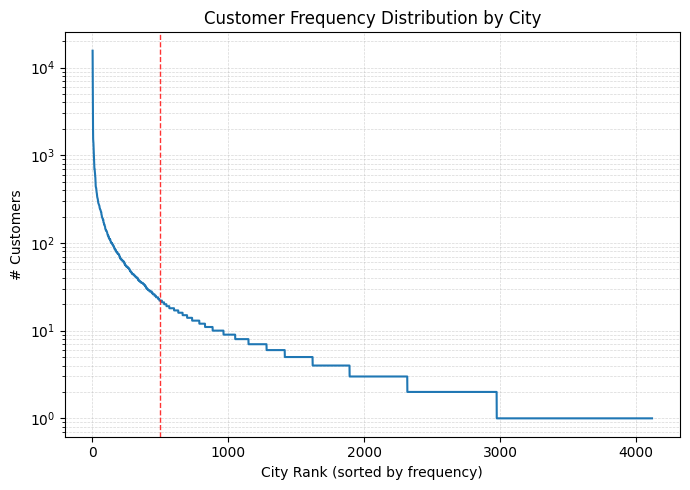

In [10]:
plt.figure(figsize=(7, 5))
ax = sns.lineplot(x=rank, y=city_counts)

ax.set_yscale("log")

ax.axvline(
    x=500,
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    color='red'
)

ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

ax.set_xlabel("City Rank (sorted by frequency)")
ax.set_ylabel("# Customers")
ax.set_title("Customer Frequency Distribution by City")

plt.tight_layout()
plt.show()

In [92]:
df_customers = df_customers.merge(
    df_geoloc,
    left_on = "customer_zip_code_prefix",
    right_on = "geolocation_zip_code_prefix",
    how = "left"
)

df_customers.drop(columns=["geolocation_zip_code_prefix"], inplace=True)
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.498489,-47.396929
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,-23.727992,-46.542848
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,-23.531642,-46.656289
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,-23.499702,-46.185233
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,-22.975100,-47.142925


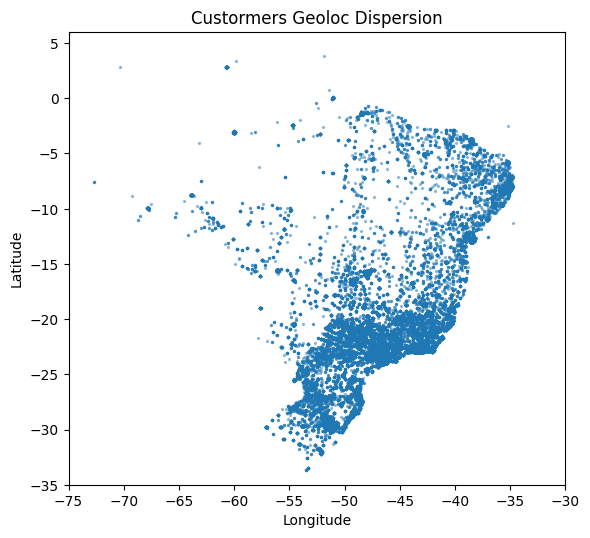

In [94]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df_customers["geolocation_lng"],
    df_customers["geolocation_lat"],
    s=2,
    alpha=0.4
)

plt.xlim(-75, -30)
plt.ylim(-35, 6)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Custormers Geoloc Dispersion")

plt.gca().set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

## Orders

In [12]:
print(dfs['olist_order_items_dataset'].shape)
dfs['olist_order_items_dataset'].head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [24]:
dfs['olist_order_items_dataset'][dfs['olist_order_items_dataset'].order_id == 'fffb9224b6fc7c43ebb0904318b10b5f']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.0,34.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.0,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.0,34.19
112643,fffb9224b6fc7c43ebb0904318b10b5f,4,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.0,34.19


In [13]:
df_items_orders = dfs['olist_order_items_dataset'].merge(
    dfs['olist_products_dataset'],
    how = 'left',
    on = 'product_id'
)

print(df_items_orders.shape)
df_items_orders.head()

(112650, 15)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [14]:
df_items_orders = df_items_orders.merge(
    dfs['product_category_name_translation'],
    how = 'left',
    on = 'product_category_name'
)

df_items_orders.drop(columns=["product_category_name"], inplace=True)
df_items_orders.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [15]:
df_items_orders.groupby("order_id")["product_category_name_english"].nunique().sort_values(ascending=False).head()

order_id
1d23106803c48c391366ff224513fb7f    3
76c4c846aae2dae9e87dfa492c3f5259    3
62ce4e3989a3477928510bb4d1064cc4    3
306b4ec62d908535f2bfa2877665e899    3
1fcbc88015c88c1a14d4b8ec35ea8ed7    3
Name: product_category_name_english, dtype: int64

In [16]:
df_items_orders[df_items_orders.order_id == '76c4c846aae2dae9e87dfa492c3f5259'] #fffb9224b6fc7c43ebb0904318b10b5f

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
52186,76c4c846aae2dae9e87dfa492c3f5259,1,0bcc3eeca39e1064258aa1e932269894,1f50f920176fa81dab994f9023523100,2018-08-08 14:10:22,49.90,27.52,57.0,339.0,2.0,1800.0,37.0,22.0,40.0,garden_tools
52187,76c4c846aae2dae9e87dfa492c3f5259,2,dfc9d9ea4c2fbabe7abb0066097d9905,9e6229250fedbe05838fef417b74e7fb,2018-08-14 14:10:22,169.90,34.39,54.0,797.0,1.0,3300.0,19.0,35.0,31.0,bed_bath_table
52188,76c4c846aae2dae9e87dfa492c3f5259,3,9d1893083966b9c51109f0dc6ab0b0d9,213b25e6f54661939f11710a6fddb871,2018-08-17 14:10:22,119.85,34.40,59.0,976.0,2.0,1000.0,16.0,20.0,16.0,construction_tools_lights


In [17]:
cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

df_items_orders[cols].isna().sum()

product_name_lenght           1603
product_description_lenght    1603
product_photos_qty            1603
dtype: int64

In [20]:
mask_all_null = df_items_orders[cols].isna().all(axis=1)
mask_any_null = df_items_orders[cols].isna().any(axis=1)

mask_all_null.sum() == mask_any_null.sum()

np.True_

In [37]:
df_items_orders[(df_items_orders.product_name_lenght.isna()) & (~df_items_orders.product_photos_qty.isna())]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english


In [18]:
k = (
    df_items_orders
    .groupby(['order_id'])
    .agg({
        'price': ['sum', 'mean'],
        'freight_value': ['sum', 'mean'],
        'product_description_lenght': lambda x: x.isna().sum(),
        'product_id': 'count',
        'product_category_name_english': 'count',
        'product_weight_g': 'mean',
        'product_length_cm': 'mean',
        'product_height_cm': 'mean',
        'product_width_cm': 'mean'
    })
)

k.columns = [
    'total_price',
    'avg_price',
    'total_freight',
    'avg_freight',
    'n_items_missing_info',
    'n_items',
    'n_item_distinct_categ',
    'avg_weight',
    'avg_length',
    'avg_height',
    'avg_width'
]

k = k.reset_index()

In [19]:
k[(k.n_items != k.n_item_distinct_categ) & (k.n_item_distinct_categ > 0)]

,order_id,total_price,avg_price,total_freight,avg_freight,n_items_missing_info,n_items,n_item_distinct_categ,avg_weight,avg_length,avg_height,avg_width
4275,0b01066982af6f2681ea9b0169f0d987,74.90,24.966667,54.69,18.230,1,3,2,300.0,16.0,2.0,11.0
4930,0ca8999f0176e37f35b6e49a9b2569da,58.96,11.792000,39.85,7.970,3,5,2,320.0,16.8,5.0,14.4
7151,1272198ea0829564b49fe8bb6ad3ea27,82.89,41.445000,25.21,12.605,1,2,1,1250.0,23.5,33.5,19.5
7931,1498068c608b11a2902e212d4d65d62c,322.81,161.405000,87.38,43.690,1,2,1,15250.0,36.0,27.5,45.0
8338,15a1cd1da2bcaccc711512ecb5701c5d,43.64,21.820000,37.54,18.770,1,2,1,520.0,23.0,8.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...
89096,e6e7ffc09203a472e7a298a12281363d,77.99,38.995000,33.77,16.885,1,2,1,362.5,24.5,18.0,20.0
90857,eb9afe3c048ef7be0e99305193ee4ded,179.80,89.900000,41.90,20.950,1,2,1,1800.0,30.0,20.0,70.0
95801,f89be3ed1cd9bd6531cff9ffea1c8546,99.80,49.900000,36.90,18.450,1,2,1,1425.0,30.0,5.0,30.0
97197,fc3078fa5d882e59237a658341f57738,198.00,99.000000,84.14,42.070,1,2,1,2000.0,39.0,42.0,39.0


`shipping_limit_date` : Prazo máximo que o vendedor tem para despachar o item após a confirmação do pagamento.

In [50]:
df_items_orders[df_items_orders.order_id == '0ca8999f0176e37f35b6e49a9b2569da']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
5610,0ca8999f0176e37f35b6e49a9b2569da,1,ff6caf9340512b8bf6d2a2a6df032cfa,38e6dada03429a47197d5d584d793b41,2017-10-13 10:49:27,7.79,8.85,NaN,NaN,NaN,200.0,16.0,5.0,12.0,NaN
5611,0ca8999f0176e37f35b6e49a9b2569da,2,b88d27345de2feed45475bb48cca74b1,38e6dada03429a47197d5d584d793b41,2017-10-13 10:49:27,14.01,8.86,55.0,787.0,2.0,300.0,16.0,5.0,17.0,stationery
5612,0ca8999f0176e37f35b6e49a9b2569da,3,90a57d62c9b9f884fae33a10dff953b4,38e6dada03429a47197d5d584d793b41,2017-10-13 10:49:27,15.36,4.43,NaN,NaN,NaN,600.0,20.0,5.0,14.0,NaN
5613,0ca8999f0176e37f35b6e49a9b2569da,4,b88d27345de2feed45475bb48cca74b1,38e6dada03429a47197d5d584d793b41,2017-10-13 10:49:27,14.01,8.86,55.0,787.0,2.0,300.0,16.0,5.0,17.0,stationery
5614,0ca8999f0176e37f35b6e49a9b2569da,5,ff6caf9340512b8bf6d2a2a6df032cfa,38e6dada03429a47197d5d584d793b41,2017-10-13 10:49:27,7.79,8.85,NaN,NaN,NaN,200.0,16.0,5.0,12.0,NaN


In [51]:
dfs['olist_orders_dataset'][dfs['olist_orders_dataset'].order_id == '0ca8999f0176e37f35b6e49a9b2569da']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
96871,0ca8999f0176e37f35b6e49a9b2569da,750f02af7b06bb81d84d3e44b9afc6d3,delivered,2017-10-06 10:52:01,2017-10-07 10:49:27,2017-10-20 20:33:58,2017-10-24 13:36:19,2017-10-24 00:00:00


In [ ]:
dfs['olist_orders_dataset'][dfs['olist_orders_dataset'].order_status == 'canceled']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaN,2018-08-14 00:00:00
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaN,2018-02-22 00:00:00
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaN,2018-02-23 00:00:00
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00
...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaN,2017-03-30 00:00:00
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00


## Payments

- `payment_sequential`: Ordem dos pagamentos dentro da mesma order.
- `payment_type`: Forma de pagamento utilizada.
- `payment_installments`: Número de parcelas.
- `payment_value`: Valor pago na respectiva transação.

In [23]:
df_payments = dfs['olist_order_payments_dataset'].copy()

print(df_payments.shape)
df_payments.head()

(103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [24]:
df_payments[df_payments.duplicated(subset='order_id', keep=False)].sort_values(by='order_id')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
80856,0016dfedd97fc2950e388d2971d718c7,2,voucher,1,17.92
89575,0016dfedd97fc2950e388d2971d718c7,1,credit_card,5,52.63
20036,002f19a65a2ddd70a090297872e6d64e,1,voucher,1,44.11
98894,002f19a65a2ddd70a090297872e6d64e,2,voucher,1,33.18
30155,0071ee2429bc1efdc43aa3e073a5290e,2,voucher,1,92.44
...,...,...,...,...,...
21648,ffa1dd97810de91a03abd7bd76d2fed1,2,voucher,1,418.73
32912,ffa39020fe7c8a3e907320e1bec4b985,1,credit_card,1,7.13
3009,ffa39020fe7c8a3e907320e1bec4b985,2,voucher,1,64.01
75188,ffc730a0615d28ec19f9cad02cb41442,1,credit_card,1,14.76


In [73]:
order_payment_types = (
    df_payments.groupby("order_id")["payment_type"]
    .nunique()
)

single_count = (order_payment_types == 1).sum()
multiple_count = (order_payment_types > 1).sum()

counts_orders = {
    "n = 1": single_count,
    "n > 1": multiple_count
}

total_orders = single_count + multiple_count

In [74]:
counts_payments = df_payments["payment_type"].value_counts()
total_payments = counts_payments.sum()

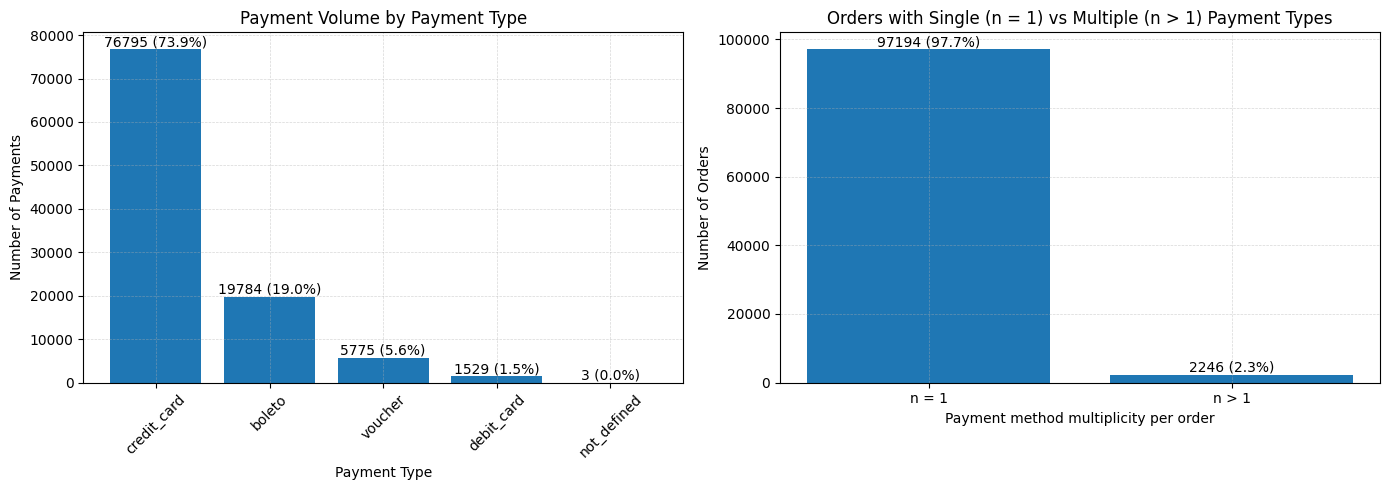

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== Gráfico 1 (agora Payment Type à esquerda) =====
bars1 = axes[0].bar(counts_payments.index, counts_payments.values)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height} ({height/total_payments:.1%})",
        ha='center',
        va='bottom'
    )

axes[0].set_xlabel("Payment Type")
axes[0].set_ylabel("Number of Payments")
axes[0].set_title("Payment Volume by Payment Type")
axes[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

# ===== Gráfico 2 (Single vs Multiple à direita) =====
bars2 = axes[1].bar(counts_orders.keys(), counts_orders.values())

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height} ({height/total_orders:.1%})",
        ha='center',
        va='bottom'
    )

axes[1].set_xlabel("Payment method multiplicity per order")
axes[1].set_ylabel("Number of Orders")
axes[1].set_title("Orders with Single (n = 1) vs Multiple (n > 1) Payment Types")
axes[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
freq_pmts_seq = df_payments['payment_sequential'].value_counts().sort_index()
cum_pct = freq_pmts_seq.cumsum() / freq_pmts_seq.sum()
rank = np.arange(1, len(freq_pmts_seq) + 1)

In [ ]:
# =========================
# 2) Percentual por payment_type (n = 1 vs n > 1)
# =========================

# Número de pagamentos por order
order_n_payments = df_payments.groupby("order_id")["payment_sequential"].max()

# Classificação n=1 vs n>1
order_group = np.where(order_n_payments == 1, "n = 1", "n > 1")
order_group = dict(zip(order_n_payments.index, order_group))

# Payment type principal por order
order_primary_payment_type = (
    df_payments.groupby("order_id")["payment_type"]
    .agg(lambda s: s.value_counts().idxmax())
)

df_order_summary = (
    order_primary_payment_type
    .to_frame("payment_type")
    .assign(n_group=lambda d: d.index.map(order_group))
)

# Contagem por payment_type x grupo
counts = (
    df_order_summary
    .groupby(["payment_type", "n_group"])
    .size()
    .unstack(fill_value=0)
)

# Transformando em percentual dentro de cada payment_type
counts_pct = counts.div(counts.sum(axis=1), axis=0)

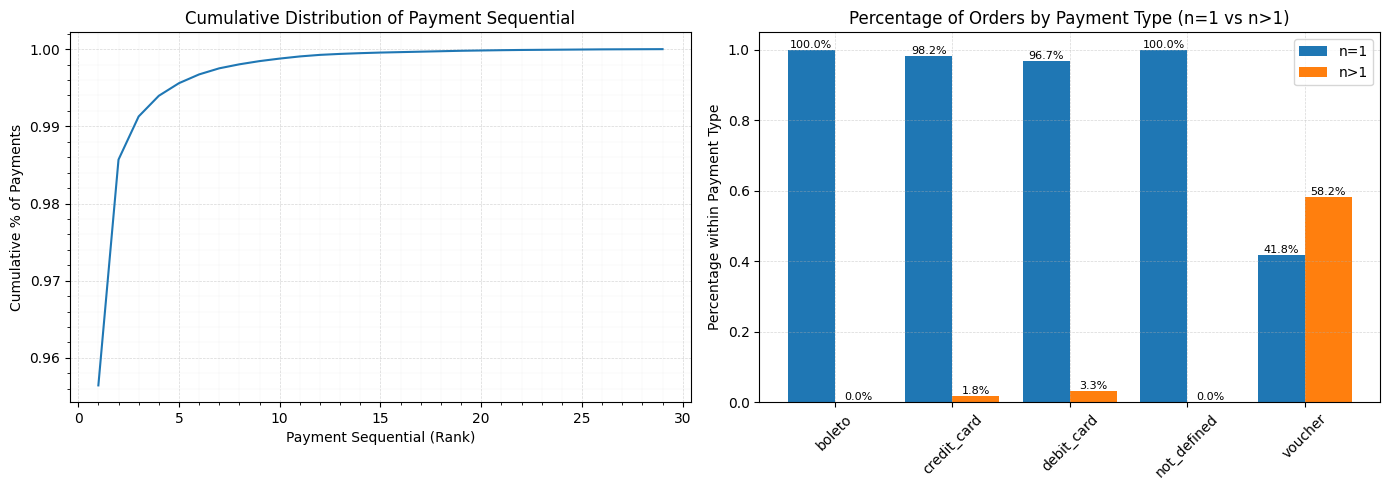

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=rank, y=cum_pct, ax=axes[0])

axes[0].grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].minorticks_on()
axes[0].grid(True, which="minor", linestyle=":", linewidth=0.3, alpha=0.4)

axes[0].set_xlabel("Payment Sequential (Rank)")
axes[0].set_ylabel("Cumulative % of Payments")
axes[0].set_title("Cumulative Distribution of Payment Sequential")

x = np.arange(len(counts_pct.index))
width = 0.4
bars1 = axes[1].bar(x - width/2, counts_pct.get("n = 1", 0), width, label="n = 1")
bars2 = axes[1].bar(x + width/2, counts_pct.get("n > 1", 0), width, label="n > 1")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=8
        )

axes[1].set_xticks(x)
axes[1].set_xticklabels(counts_pct.index, rotation=45)
axes[1].set_ylabel("Percentage within Payment Type")
axes[1].set_title("Percentage of Orders by Payment Type (n=1 vs n>1)")
axes[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
df_payments[
    (df_payments['payment_sequential'] > 1) & (df_payments['payment_type'].isin(['credit_card', 'debit_card']))
]['payment_type'].value_counts()

payment_type
credit_card    319
debit_card      52
Name: count, dtype: int64

In [ ]:
# =========================
# 1) Cumulative Distribution of payment_installments
# =========================

freq_inst = df_payments['payment_installments'].value_counts().sort_index()
cum_pct = freq_inst.cumsum() / freq_inst.sum()
rank = np.arange(1, len(freq_inst) + 1)

In [88]:
counts = (
    df_payments.assign(n_group=np.where(df_payments["payment_installments"] == 1, "n = 1", "n > 1"))
    .groupby(["payment_type", "n_group"])
    .size()
    .unstack(fill_value=0)
)

counts_pct = counts.div(counts.sum(axis=1), axis=0)

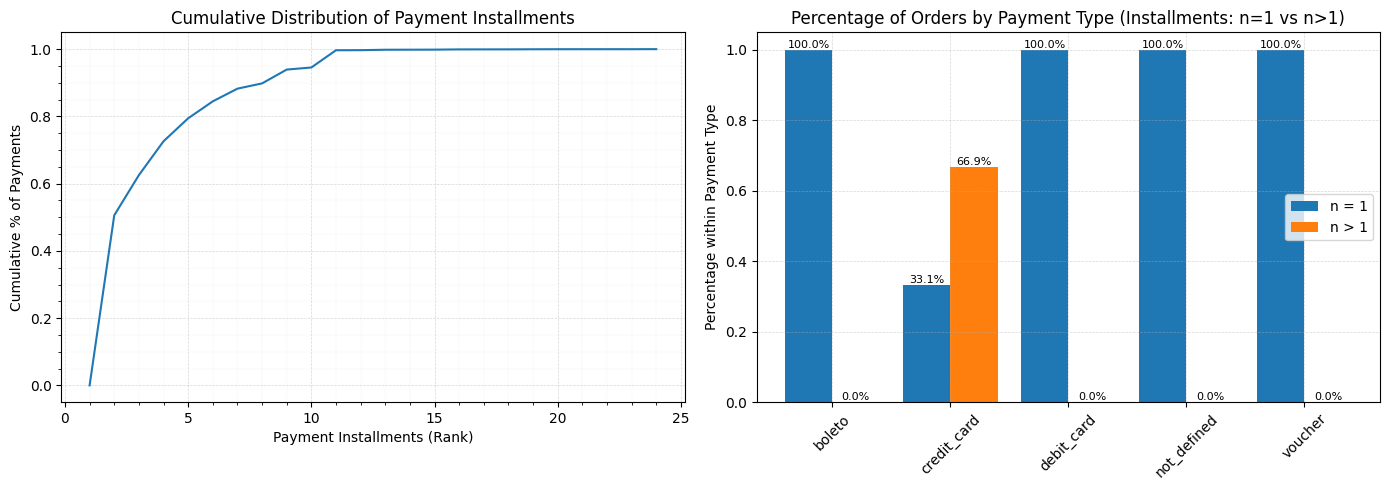

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=rank, y=cum_pct, ax=axes[0])

axes[0].grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].minorticks_on()
axes[0].grid(True, which="minor", linestyle=":", linewidth=0.3, alpha=0.4)

axes[0].set_xlabel("Payment Installments (Rank)")
axes[0].set_ylabel("Cumulative % of Payments")
axes[0].set_title("Cumulative Distribution of Payment Installments")

x = np.arange(len(counts_pct.index))
width = 0.4
bars1 = axes[1].bar(x - width/2, counts_pct.get("n = 1", 0), width, label="n = 1")
bars2 = axes[1].bar(x + width/2, counts_pct.get("n > 1", 0), width, label="n > 1")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=8
        )

axes[1].set_xticks(x)
axes[1].set_xticklabels(counts_pct.index, rotation=45)
axes[1].set_ylabel("Percentage within Payment Type")
axes[1].set_title("Percentage of Orders by Payment Type (Installments: n=1 vs n>1)")
axes[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

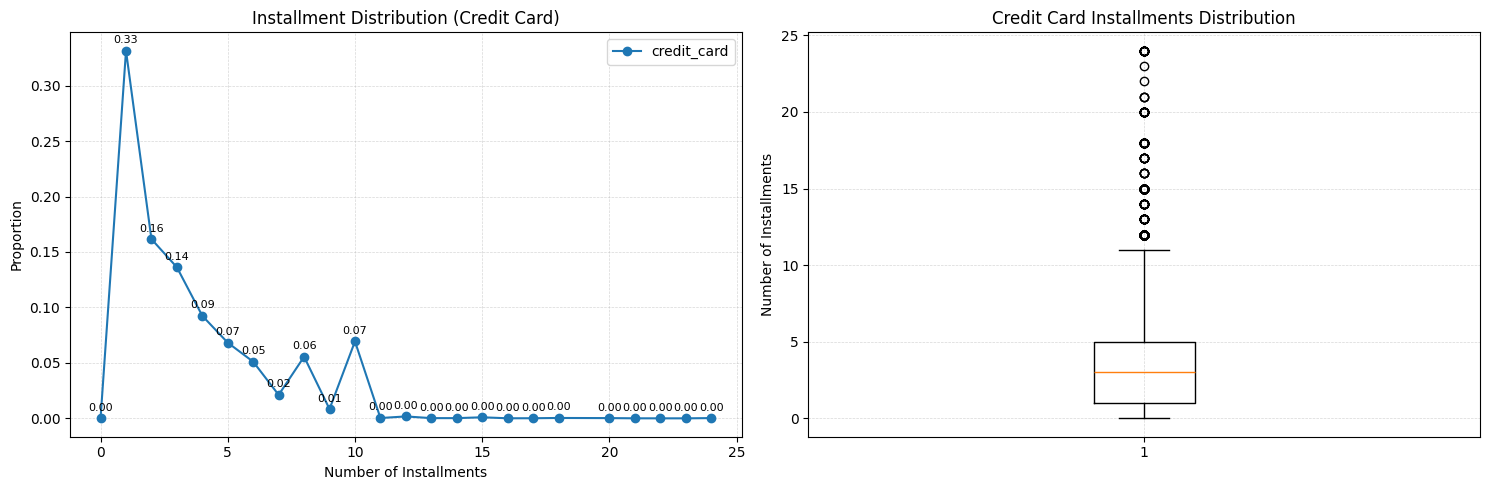

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

values = (
    df_payments[df_payments['payment_type'] == 'credit_card']
    ['payment_installments']
    .value_counts(normalize=True)
    .sort_index()
)

x, y = values.index, values.values

axes[0].plot(x, y, marker='o', label='credit_card')

for xi, yi in zip(x, y):
    axes[0].text(
        xi, yi + 0.005,
        f"{yi:.2f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

axes[0].set_xlabel("Number of Installments")
axes[0].set_ylabel("Proportion")
axes[0].set_title("Installment Distribution (Credit Card)")
axes[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
axes[0].legend()


cc_installments = df_payments.loc[
    df_payments["payment_type"] == "credit_card",
    "payment_installments"
]

axes[1].boxplot(cc_installments, vert=True)

axes[1].set_ylabel("Number of Installments")
axes[1].set_title("Credit Card Installments Distribution")
axes[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
payments_agg = (
    df_payments
    .groupby("order_id")
    .agg({
        'payment_value': ['sum', 'mean'],
        'payment_installments': 'max',
        'payment_type': 'count'   
    })
)

payments_agg.columns = [
    'total_payment',
    'avg_payment',
    'max_installments',
    'n_payments_type',
]


99440


## Reviews

As variáveis relacionadas às avaliações (reviews) devem ser analisadas com cautela, pois geralmente são registradas apenas após a conclusão da jornada do pedido, independentemente de o pedido ter sido entregue ou não.

Sendo assim, o grupo decidiu não utilizá-la como covariável.

In [13]:
df_reviews = dfs['olist_order_reviews_dataset'].copy()

print(df_reviews.shape)
df_reviews.head()

(99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [18]:
df_reviews = (
    df_reviews
    .groupby("order_id")
    .agg({
        "review_score": "mean"
    })
    .reset_index()
)

df_reviews

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


In [ ]:
payments_agg = (
    order_payments
    .groupby("order_id")
    .agg({
        "payment_value": ["sum", "mean"],
        "payment_installments": "max",
        
    })
)

payments_agg.columns = [
    "total_payment",
    "avg_payment",
    "max_installments"
]

payments_agg = payments_agg.reset_index()